In [395]:
#Import libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [396]:
# Load the dataset
data = pd.read_csv('../data/laptop_price.csv', encoding='latin-1')


In [398]:
# Display the first few rows of the dataset
data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [399]:
#Display the Information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [400]:
#Checking for missing values.
data.isnull().sum().sum()


np.int64(0)

In [401]:
#Check the statistical summary of the dataset
data.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [402]:
# Check the Duplicate values in the dataset
data.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

In [403]:
# Droping the unwanted columns

data.drop(columns=['laptop_ID'], inplace=True)

In [404]:
data.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [405]:
# Extract Resolution Text

data['Resolution'] = data['ScreenResolution'].str.extract(r'(\d+x\d+)')

In [406]:
data.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Resolution
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,2560x1600
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,1440x900
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,1920x1080
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,2880x1800
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,2560x1600


# Feature Engineering

In [407]:
# Creating the different resolutions like X_Resolution & Y_Resolution

data[['X_Resolution', 'Y_Resolution']] = data['Resolution'].str.split('x', expand=True)

In [408]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   Product           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price_euros       1303 non-null   float64
 12  Resolution        1303 non-null   object 
 13  X_Resolution      1303 non-null   object 
 14  Y_Resolution      1303 non-null   object 
dtypes: float64(2), object(13)
memory usage: 152.8+ KB


In [409]:
# Converting the X_Resolution & Y_Resolution into integer format

data['X_Resolution'] = data['X_Resolution'].astype(int)

data['Y_Resolution'] = data['Y_Resolution'].astype(int)

In [410]:
# Creating IPS and Touchscreen Features

data['IPS'] = data['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

data['Touchscreen'] = data['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)



In [ ]:
data.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Resolution,X_Resolution,Y_Resolution,IPS,Touchscreen
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,2560x1600,2560,1600,1,1
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,1440x900,1440,900,0,1
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,1920x1080,1920,1080,0,1
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,2880x1800,2880,1800,1,1
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,2560x1600,2560,1600,1,1


In [ ]:
data['PPI'] = (np.sqrt(data['X_Resolution']**2 + data['Y_Resolution']**2)/ data['Inches'])

In [ ]:
# Droping the ScreenResolution columns as New columns extraced and created from that

data.drop(columns=['ScreenResolution'], inplace=True)


In [ ]:
data.head()

,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Resolution,X_Resolution,Y_Resolution,IPS,Touchscreen,PPI
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,2560x1600,2560,1600,1,1,226.983005
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,1440x900,1440,900,0,1,127.677940
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,1920x1080,1920,1080,0,1,141.211998
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,2880x1800,2880,1800,1,1,220.534624
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,2560x1600,2560,1600,1,1,226.983005


In [ ]:
# Creating new columns from the CPU columns

data['CPU_Brand'] = data['Cpu'].apply(lambda x: x.split()[0])

In [412]:
# Extract CPU Series by creating the functions

def Cpu_Series(text):
    text = text.lower()
    
    if 'i3' in text:
     return 'i3'
    if 'i5' in text:
        return 'i5'
    if 'i7' in text:
        return 'i7'
    if 'i9' in text:
        return 'i9'
    if 'ryzen' in text:
        return 'Ryzen'
    if 'AMD' in text:
        return 'AMD'
    if 'celeron' in text:
        return 'Celeron'
    else:
        return ' Other'
    
     

In [ ]:
data['Cpu_Series'] = data['Cpu'].apply(Cpu_Series)

In [ ]:
data.Cpu_Series.value_counts()

Cpu_Series
i7         527
i5         423
i3         136
 Other     125
Celeron     88
Ryzen        4
Name: count, dtype: int64

In [ ]:
data['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [ ]:
data['SSD'] = data['Memory'].apply(lambda x: x.split()[0])

In [ ]:
data.head()

,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Resolution,X_Resolution,Y_Resolution,IPS,Touchscreen,PPI,CPU_Brand,Cpu_Series,SSD
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,2560x1600,2560,1600,1,1,226.983005,Intel,i5,128GB
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,1440x900,1440,900,0,1,127.677940,Intel,i5,128GB
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,1920x1080,1920,1080,0,1,141.211998,Intel,i5,256GB
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,2880x1800,2880,1800,1,1,220.534624,Intel,i7,512GB
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,2560x1600,2560,1600,1,1,226.983005,Intel,i5,256GB


In [ ]:
def Memory_Type(text):
    text = text.lower()
    
    if 'ssd' in text:
        return 'SSD'
    if 'hdd' in text:
        return 'HDD'
    if 'hybrid' in text:
        return 'Hybrid'
    if 'flash' in text:
        return 'Flash Storage'
    else:
        return 'Other'

In [ ]:
data['Memory_Type'] = data['Memory'].apply(Memory_Type)

In [ ]:
data.head()

,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,Resolution,X_Resolution,Y_Resolution,IPS,Touchscreen,PPI,CPU_Brand,Cpu_Series,SSD,Memory_Type
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,...,2560x1600,2560,1600,1,1,226.983005,Intel,i5,128GB,SSD
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,...,1440x900,1440,900,0,1,127.677940,Intel,i5,128GB,Flash Storage
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,...,1920x1080,1920,1080,0,1,141.211998,Intel,i5,256GB,SSD
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,...,2880x1800,2880,1800,1,1,220.534624,Intel,i7,512GB,SSD
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,...,2560x1600,2560,1600,1,1,226.983005,Intel,i5,256GB,SSD


In [ ]:
data.Memory_Type.value_counts()

Memory_Type
SSD              843
HDD              376
Flash Storage     74
Hybrid            10
Name: count, dtype: int64

In [ ]:
# Extracting the columns from the Gpu

data.Gpu.value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [ ]:
data['Gpu_Brand'] = data['Gpu'].apply(lambda x: x.split()[0])

In [ ]:
data.head()

,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,X_Resolution,Y_Resolution,IPS,Touchscreen,PPI,CPU_Brand,Cpu_Series,SSD,Memory_Type,Gpu_Brand
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,...,2560,1600,1,1,226.983005,Intel,i5,128GB,SSD,Intel
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,...,1440,900,0,1,127.677940,Intel,i5,128GB,Flash Storage,Intel
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,...,1920,1080,0,1,141.211998,Intel,i5,256GB,SSD,Intel
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,...,2880,1800,1,1,220.534624,Intel,i7,512GB,SSD,AMD
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,...,2560,1600,1,1,226.983005,Intel,i5,256GB,SSD,Intel


In [ ]:
data.Gpu.unique()

array(['Intel Iris Plus Graphics 640', 'Intel HD Graphics 6000',
       'Intel HD Graphics 620', 'AMD Radeon Pro 455',
       'Intel Iris Plus Graphics 650', 'AMD Radeon R5',
       'Intel Iris Pro Graphics', 'Nvidia GeForce MX150',
       'Intel UHD Graphics 620', 'Intel HD Graphics 520',
       'AMD Radeon Pro 555', 'AMD Radeon R5 M430',
       'Intel HD Graphics 615', 'AMD Radeon Pro 560',
       'Nvidia GeForce 940MX', 'Intel HD Graphics 400',
       'Nvidia GeForce GTX 1050', 'AMD Radeon R2', 'AMD Radeon 530',
       'Nvidia GeForce 930MX', 'Intel HD Graphics',
       'Intel HD Graphics 500', 'Nvidia GeForce 930MX ',
       'Nvidia GeForce GTX 1060', 'Nvidia GeForce 150MX',
       'Intel Iris Graphics 540', 'AMD Radeon RX 580',
       'Nvidia GeForce 920MX', 'AMD Radeon R4 Graphics', 'AMD Radeon 520',
       'Nvidia GeForce GTX 1070', 'Nvidia GeForce GTX 1050 Ti',
       'Nvidia GeForce MX130', 'AMD R4 Graphics',
       'Nvidia GeForce GTX 940MX', 'AMD Radeon RX 560',
       'Nvid

In [ ]:
#  Extracting the model numbers and names from the Gpu column

def Gpu_type(text):
    text = text.lower()
    
    if 'nvidia' in text:
        return 'Nvidia'
    if 'amd' in text:
        return 'AMD'
    if 'gtx' in text:
        return 'GTX'
    if 'intel' in text:
        return 'Intel'
    if 'mx' in text:
        return 'MX'
    if 'radeon' in text:
        return 'Radeon'
    if 'quadro' in text:
        return 'Quadro'
    else:
        return 'Other'
    

In [ ]:
data['Gpu_Type'] = data['Gpu'].apply(Gpu_type)

In [ ]:
data.head()

,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,Y_Resolution,IPS,Touchscreen,PPI,CPU_Brand,Cpu_Series,SSD,Memory_Type,Gpu_Brand,Gpu_Type
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,...,1600,1,1,226.983005,Intel,i5,128GB,SSD,Intel,Intel
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,...,900,0,1,127.677940,Intel,i5,128GB,Flash Storage,Intel,Intel
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,...,1080,0,1,141.211998,Intel,i5,256GB,SSD,Intel,Intel
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,...,1800,1,1,220.534624,Intel,i7,512GB,SSD,AMD,AMD
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,...,1600,1,1,226.983005,Intel,i5,256GB,SSD,Intel,Intel


In [ ]:
data.Gpu_Type.value_counts()

Gpu_Type
Intel     722
Nvidia    400
AMD       180
Other       1
Name: count, dtype: int64

In [ ]:
data[['Gpu', 'Gpu_Type']].head(10)

,Gpu,Gpu_Type
0,Intel Iris Plus Graphics 640,Intel
1,Intel HD Graphics 6000,Intel
2,Intel HD Graphics 620,Intel
3,AMD Radeon Pro 455,AMD
4,Intel Iris Plus Graphics 650,Intel
5,AMD Radeon R5,AMD
6,Intel Iris Pro Graphics,Intel
7,Intel HD Graphics 6000,Intel
8,Nvidia GeForce MX150,Nvidia
9,Intel UHD Graphics 620,Intel


In [ ]:
def gpu_series(text):
    text = text.lower()

    if 'rtx' in text:
        return 'RTX'
    elif 'gtx' in text:
        return 'GTX'
    elif 'mx' in text:
        return 'MX'
    elif 'quadro' in text:
        return 'Quadro'
    elif 'radeon' in text:
        return 'Radeon'
    elif 'uhd' in text:
        return 'UHD'
    elif 'hd graphics' in text:
        return 'HD Graphics'
    else:
        return 'Other'

data['Gpu_Series'] = data['Gpu'].apply(gpu_series)

In [ ]:
data.Gpu_Series.value_counts()

Gpu_Series
HD Graphics    639
GTX            239
Radeon         173
MX             115
UHD             68
Other           38
Quadro          31
Name: count, dtype: int64

In [ ]:
data.head()

,Company,Product,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,IPS,Touchscreen,PPI,CPU_Brand,Cpu_Series,SSD,Memory_Type,Gpu_Brand,Gpu_Type,Gpu_Series
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,...,1,1,226.983005,Intel,i5,128GB,SSD,Intel,Intel,Other
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,...,0,1,127.677940,Intel,i5,128GB,Flash Storage,Intel,Intel,HD Graphics
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,...,0,1,141.211998,Intel,i5,256GB,SSD,Intel,Intel,HD Graphics
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,...,1,1,220.534624,Intel,i7,512GB,SSD,AMD,AMD,Radeon
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,...,1,1,226.983005,Intel,i5,256GB,SSD,Intel,Intel,Other


In [ ]:
# Data Preprocessing (changing the dtype of SSD).


data['SSD'] = data['SSD'].astype(str)
data['SSD'] = data['SSD'].str.replace('GB','', regex=False)
data['SSD'] = data['SSD'].str.replace('TB','', regex=False)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company       1303 non-null   object 
 1   Product       1303 non-null   object 
 2   TypeName      1303 non-null   object 
 3   Inches        1303 non-null   float64
 4   Cpu           1303 non-null   object 
 5   Ram           1303 non-null   object 
 6   Memory        1303 non-null   object 
 7   Gpu           1303 non-null   object 
 8   OpSys         1303 non-null   object 
 9   Weight        1303 non-null   object 
 10  Price_euros   1303 non-null   float64
 11  Resolution    1303 non-null   object 
 12  X_Resolution  1303 non-null   int64  
 13  Y_Resolution  1303 non-null   int64  
 14  IPS           1303 non-null   int64  
 15  Touchscreen   1303 non-null   int64  
 16  PPI           1303 non-null   float64
 17  CPU_Brand     1303 non-null   object 
 18  Cpu_Series    1303 non-null 

In [ ]:
cols_to_drop = [
    'Cpu',
    'Memory',
    'Gpu',
    'Resolution'
]

data.drop(columns=cols_to_drop, inplace=True)

In [ ]:
# Changing the dtype of SSD

data['SSD'] = data['SSD'].astype(float)

In [ ]:
data.head()

,Company,Product,TypeName,Inches,Ram,OpSys,Weight,Price_euros,X_Resolution,Y_Resolution,IPS,Touchscreen,PPI,CPU_Brand,Cpu_Series,SSD,Memory_Type,Gpu_Brand,Gpu_Type,Gpu_Series
0,Apple,MacBook Pro,Ultrabook,13.3,8GB,macOS,1.37kg,1339.69,2560,1600,1,1,226.983005,Intel,i5,128.0,SSD,Intel,Intel,Other
1,Apple,Macbook Air,Ultrabook,13.3,8GB,macOS,1.34kg,898.94,1440,900,0,1,127.677940,Intel,i5,128.0,Flash Storage,Intel,Intel,HD Graphics
2,HP,250 G6,Notebook,15.6,8GB,No OS,1.86kg,575.00,1920,1080,0,1,141.211998,Intel,i5,256.0,SSD,Intel,Intel,HD Graphics
3,Apple,MacBook Pro,Ultrabook,15.4,16GB,macOS,1.83kg,2537.45,2880,1800,1,1,220.534624,Intel,i7,512.0,SSD,AMD,AMD,Radeon
4,Apple,MacBook Pro,Ultrabook,13.3,8GB,macOS,1.37kg,1803.60,2560,1600,1,1,226.983005,Intel,i5,256.0,SSD,Intel,Intel,Other


In [ ]:
# Data Preprocessing (changing the dtype of Ram, weight).


data['Ram'] = data['Ram'].astype(str)
data['Ram'] = data['Ram'].str.replace('GB','', regex=False)
data['Ram'] = data['Ram'].astype(int)

data['Weight'] = data['Weight'].astype(str)
data['Weight'] = data['Weight'].str.replace('kg','', regex=False)
data['Weight'] = data['Weight'].astype(float)

In [ ]:
data['Ram'].head()
data['Weight'].head()
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company       1303 non-null   object 
 1   Product       1303 non-null   object 
 2   TypeName      1303 non-null   object 
 3   Inches        1303 non-null   float64
 4   Ram           1303 non-null   int64  
 5   OpSys         1303 non-null   object 
 6   Weight        1303 non-null   float64
 7   Price_euros   1303 non-null   float64
 8   X_Resolution  1303 non-null   int64  
 9   Y_Resolution  1303 non-null   int64  
 10  IPS           1303 non-null   int64  
 11  Touchscreen   1303 non-null   int64  
 12  PPI           1303 non-null   float64
 13  CPU_Brand     1303 non-null   object 
 14  Cpu_Series    1303 non-null   object 
 15  SSD           1303 non-null   float64
 16  Memory_Type   1303 non-null   object 
 17  Gpu_Brand     1303 non-null   object 
 18  Gpu_Type      1303 non-null 

In [ ]:
data.head()

,Company,Product,TypeName,Inches,Ram,OpSys,Weight,Price_euros,X_Resolution,Y_Resolution,IPS,Touchscreen,PPI,CPU_Brand,Cpu_Series,SSD,Memory_Type,Gpu_Brand,Gpu_Type,Gpu_Series
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,2560,1600,1,1,226.983005,Intel,i5,128.0,SSD,Intel,Intel,Other
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,1440,900,0,1,127.677940,Intel,i5,128.0,Flash Storage,Intel,Intel,HD Graphics
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,1920,1080,0,1,141.211998,Intel,i5,256.0,SSD,Intel,Intel,HD Graphics
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,2880,1800,1,1,220.534624,Intel,i7,512.0,SSD,AMD,AMD,Radeon
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,2560,1600,1,1,226.983005,Intel,i5,256.0,SSD,Intel,Intel,Other


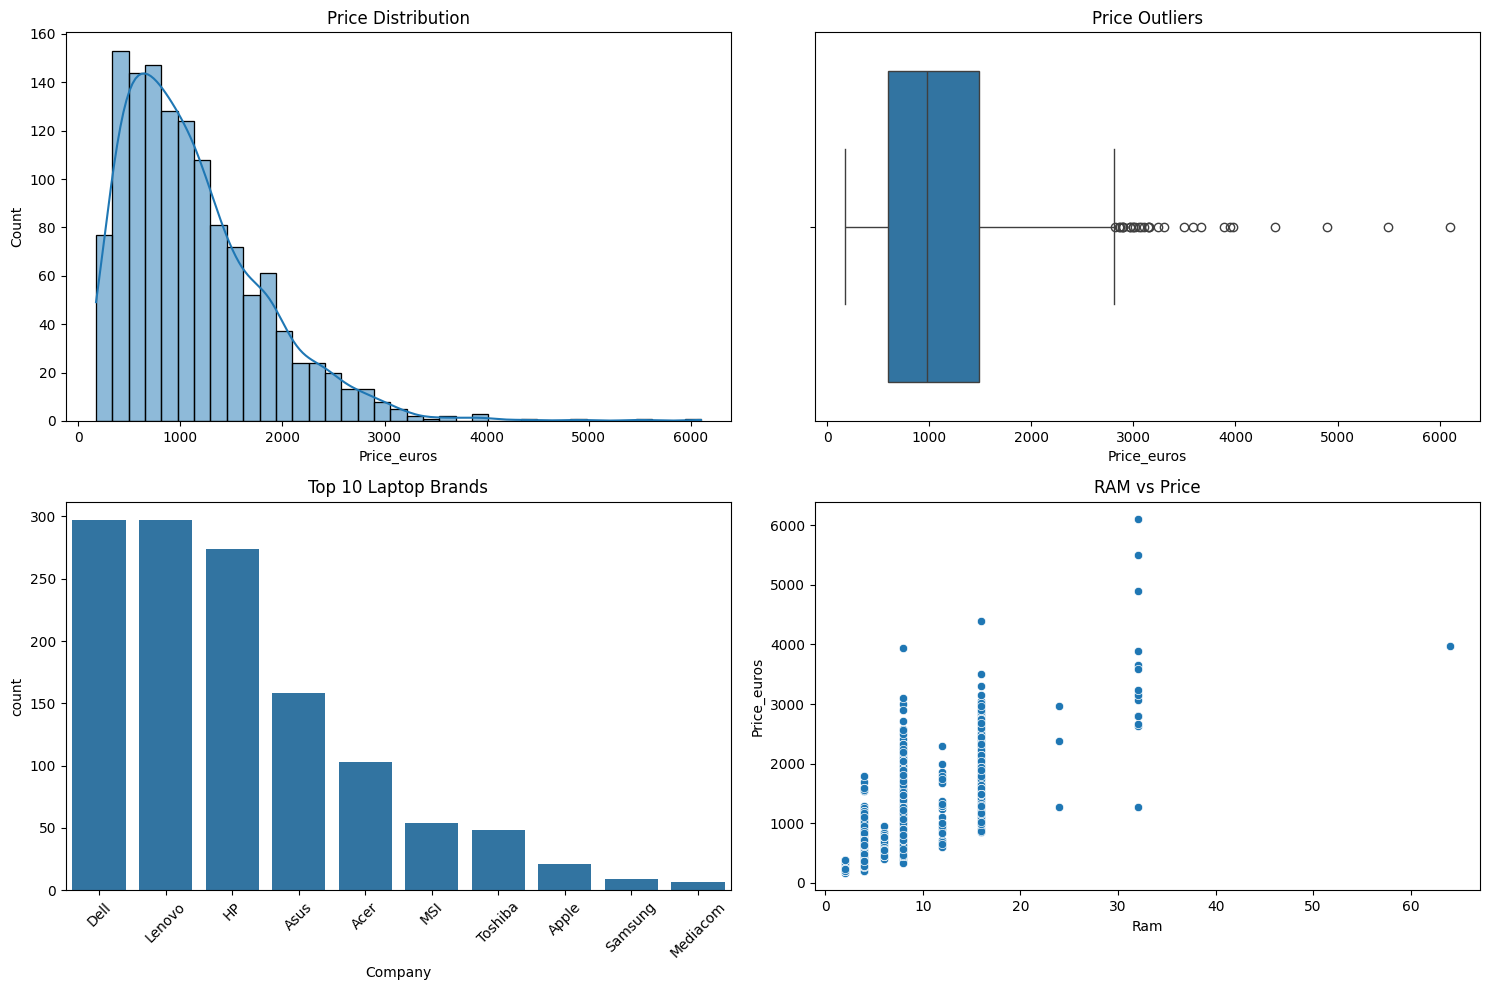

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# 1
sns.histplot(data['Price_euros'], kde=True, ax=ax[0,0])
ax[0,0].set_title('Price Distribution')

# 2
sns.boxplot(x=data['Price_euros'], ax=ax[0,1])
ax[0,1].set_title('Price Outliers')

# 3
sns.countplot(
    data=data,
    x='Company',
    order=data['Company'].value_counts().head(10).index,
    ax=ax[1,0]
)
ax[1,0].set_title('Top 10 Laptop Brands')
ax[1,0].tick_params(axis='x', rotation=45)

# 4
sns.scatterplot(
    x='Ram',
    y='Price_euros',
    data=data,
    ax=ax[1,1]
)
ax[1,1].set_title('RAM vs Price')

plt.tight_layout()
plt.show()

In [ ]:
# Subplots of EDA analysis
"""
The EDA plots reveal that laptop prices are positively skewed, with a small number of expensive devices contributing to the long right tail. 
The boxplot highlights the presence of price outliers, primarily representing premium laptops. 
The company-wise distribution shows that the dataset is dominated by a few major brands. Additionally, 
the RAM vs Price analysis indicates a clear positive correlation, suggesting that higher RAM capacity is associated with increased laptop prices."""

'\nThe EDA plots reveal that laptop prices are positively skewed, with a small number of expensive devices contributing to the long right tail. \nThe boxplot highlights the presence of price outliers, primarily representing premium laptops. \nThe company-wise distribution shows that the dataset is dominated by a few major brands. Additionally, \nthe RAM vs Price analysis indicates a clear positive correlation, suggesting that higher RAM capacity is associated with increased laptop prices.'

In [ ]:
# Checking the skewness of the dataset

data.skew(numeric_only=True)

Inches         -0.446913
Ram             2.686806
Weight          1.144963
Price_euros     1.520866
X_Resolution    2.188046
Y_Resolution    2.099301
IPS             0.980409
Touchscreen     0.000000
PPI             2.024014
SSD             0.329392
dtype: float64

In [ ]:
data['log_price'] = np.log(data['Price_euros'])

In [ ]:
data['log_price'].skew()

np.float64(-0.17412973375365404)

In [ ]:
""" Skewness is reduced after applying log transformation to the target variable. 
    This indicates that the distribution of the target variable has become more symmetric, 
    which can be beneficial for certain machine learning algorithms that assume normality in the data."""

' Skewness is reduced after applying log transformation to the target variable. \n    This indicates that the distribution of the target variable has become more symmetric, \n    which can be beneficial for certain machine learning algorithms that assume normality in the data.'

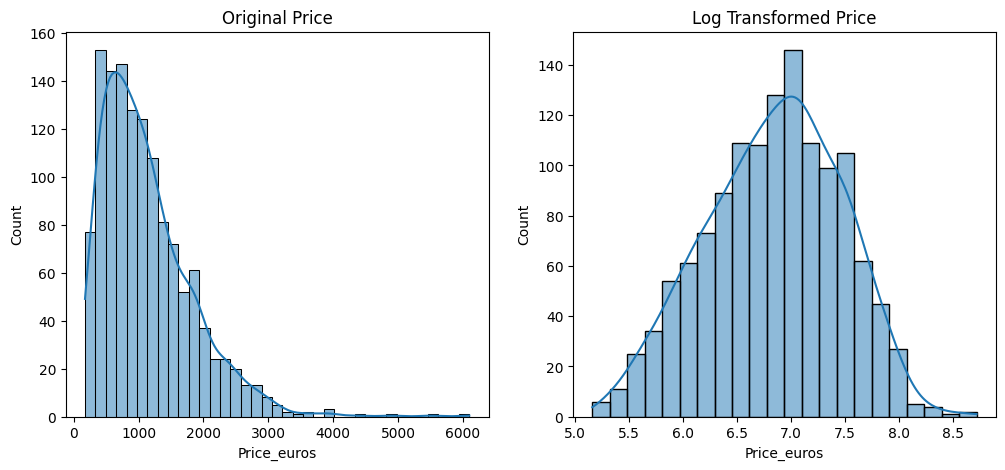

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.histplot(data['Price_euros'], kde=True, ax=ax[0])
ax[0].set_title("Original Price")

sns.histplot(np.log(data['Price_euros']), kde=True, ax=ax[1])
ax[1].set_title("Log Transformed Price")

plt.show()

In [ ]:
"""The original Price_euros distribution was positively skewed, indicating the presence of several high-priced laptops
# To reduce skewness and improve the distribution, a log transformation was applied. After transformation, 
# the skewness decreased from 1.52 to -0.17, resulting in a more symmetric and near-normal distribution. 
# This helps reduce the impact of outliers and makes the target variable more suitable for regression modelling."""

'The original Price_euros distribution was positively skewed, indicating the presence of several high-priced laptops\n# To reduce skewness and improve the distribution, a log transformation was applied. After transformation, \n# the skewness decreased from 1.52 to -0.17, resulting in a more symmetric and near-normal distribution. \n# This helps reduce the impact of outliers and makes the target variable more suitable for regression modelling.'

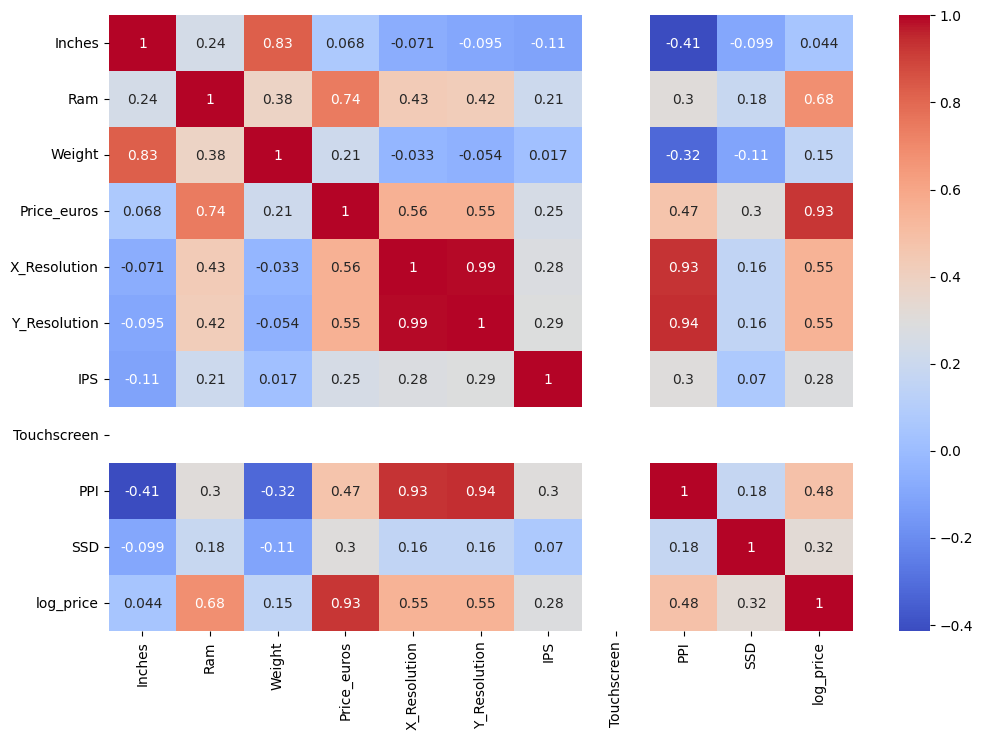

In [ ]:
num_cols = data.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

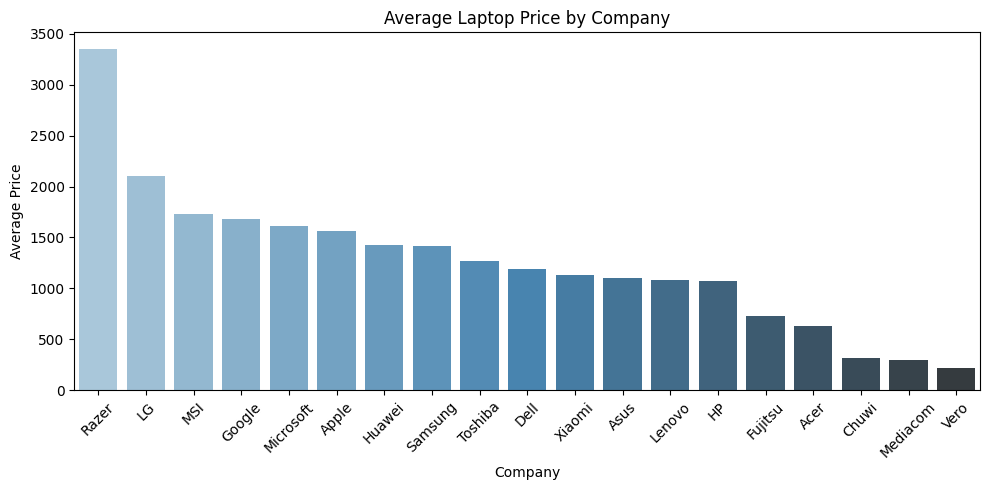

In [ ]:
company_price = data.groupby('Company')['Price_euros'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x=company_price.index,
    y=company_price.values,
    palette='Blues_d'
)

plt.title('Average Laptop Price by Company')
plt.xlabel('Company')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Plot for Average Laptop Price by Company.
"""
The original Price_euros distribution was positively skewed, with most laptops concentrated in the lower and mid-price ranges.
A few premium laptops created a long right tail, indicating the presence of high-value observations. 
To reduce skewness and improve the distribution, a logarithmic transformation was applied to the target variable. 
After transformation, the distribution became more symmetric and closer to a normal distribution. 
This helps reduce the influence of extreme values and improves the effectiveness of regression-based machine learning models."""

'\nThe original Price_euros distribution was positively skewed, with most laptops concentrated in the lower and mid-price ranges.\nA few premium laptops created a long right tail, indicating the presence of high-value observations. \nTo reduce skewness and improve the distribution, a logarithmic transformation was applied to the target variable. \nAfter transformation, the distribution became more symmetric and closer to a normal distribution. \nThis helps reduce the influence of extreme values and improves the effectiveness of regression-based machine learning models.'

In [ ]:
data.head()

,Company,Product,TypeName,Inches,Ram,OpSys,Weight,Price_euros,X_Resolution,Y_Resolution,...,Touchscreen,PPI,CPU_Brand,Cpu_Series,SSD,Memory_Type,Gpu_Brand,Gpu_Type,Gpu_Series,log_price
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,2560,1600,...,1,226.983005,Intel,i5,128.0,SSD,Intel,Intel,Other,7.200194
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,1440,900,...,1,127.677940,Intel,i5,128.0,Flash Storage,Intel,Intel,HD Graphics,6.801216
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,1920,1080,...,1,141.211998,Intel,i5,256.0,SSD,Intel,Intel,HD Graphics,6.354370
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,2880,1800,...,1,220.534624,Intel,i7,512.0,SSD,AMD,AMD,Radeon,7.838915
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,2560,1600,...,1,226.983005,Intel,i5,256.0,SSD,Intel,Intel,Other,7.497540


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company       1303 non-null   object 
 1   Product       1303 non-null   object 
 2   TypeName      1303 non-null   object 
 3   Inches        1303 non-null   float64
 4   Ram           1303 non-null   int64  
 5   OpSys         1303 non-null   object 
 6   Weight        1303 non-null   float64
 7   Price_euros   1303 non-null   float64
 8   X_Resolution  1303 non-null   int64  
 9   Y_Resolution  1303 non-null   int64  
 10  IPS           1303 non-null   int64  
 11  Touchscreen   1303 non-null   int64  
 12  PPI           1303 non-null   float64
 13  CPU_Brand     1303 non-null   object 
 14  Cpu_Series    1303 non-null   object 
 15  SSD           1303 non-null   float64
 16  Memory_Type   1303 non-null   object 
 17  Gpu_Brand     1303 non-null   object 
 18  Gpu_Type      1303 non-null 

In [ ]:
# Feature and labels

X = data.drop(columns=['Price_euros', 'log_price', 'Product'])
y = data['log_price']


In [ ]:
print(X.columns.tolist())

['Company', 'TypeName', 'Inches', 'Ram', 'OpSys', 'Weight', 'X_Resolution', 'Y_Resolution', 'IPS', 'Touchscreen', 'PPI', 'CPU_Brand', 'Cpu_Series', 'SSD', 'Memory_Type', 'Gpu_Brand', 'Gpu_Type', 'Gpu_Series']


In [ ]:
print(y.name)

log_price


In [ ]:
#Numeric and Categorical data changing its respective.

num_cols = X.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X.select_dtypes(
    include=['object']
).columns

In [ ]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Create ColumnTransformer

# Numeric using scaler

num_transformer = StandardScaler()

#Categorical Encoder

cat_transformer = OneHotEncoder(handle_unknown='ignore')


In [ ]:
# combining both Numeric and Categorical columns

preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',

            StandardScaler(),

            num_cols
        ),

        (
            'cat',

            OneHotEncoder(
                handle_unknown='ignore'
            ),

            cat_cols
        )

    ]

)



In [ ]:
# Creating a Model Slection Algorihthm

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, max_depth=5, min_samples_split=10),
    "Support Vector Machine": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=5, min_samples_split=10),
    "Ridge" : Ridge(alpha=0.5),
    "Lasso" : Lasso(alpha=0.1),
    "Kneigh" : KNeighborsRegressor()
}


In [ ]:
def evaluate_models(models):

    results = []

    for name, model in models.items():

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        train_score = pipe.score(X_train, y_train)
        test_score = pipe.score(X_test, y_test)

        results.append({
            "Model": name,
            "Train Score": round(train_score, 4),
            "Test Score": round(test_score, 4)
        })

    return pd.DataFrame(results)

In [ ]:
scores = evaluate_models(models)

print(scores)

                    Model  Train Score  Test Score
0       Linear Regression       0.8617      0.8387
1           Random Forest       0.8630      0.8133
2  Support Vector Machine       0.9428      0.8759
3           Decision Tree       0.8350      0.7716
4                   Ridge       0.8613      0.8383
5                   Lasso       0.5306      0.5404
6                  Kneigh       0.9025      0.8130


In [ ]:
# As per above results Ridge is showing the best score amongst all Algo, So Proceed with Ridge model next step is to do the Hyperparameter tuning for Ridge model.

In [ ]:
# creating the final pipeline for RIDGE Which is find the best among all

best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

best_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Cross Validation score

cv = cross_val_score(best_pipe, X_train, y_train, cv=5, scoring='r2')
print("The cross val score", cv)
print("Mean", cv.mean())

The cross val score [0.83997096 0.87222559 0.85823906 0.83725731 0.80510319]
Mean 0.8425592202651968


In [ ]:
# Cross Validation score for Ridge Regression model Insights/
"""
The Ridge Regression model achieved a mean cross-validation R² score of 0.8878, indicating strong predictive performance on the laptop price dataset.
The cross-validation scores remained consistent across all five folds, ranging from 0.8672 to 0.9131, which demonstrates stable model behavior across different subsets of the data.
The relatively small variation between fold scores suggests that the model generalizes well and is not heavily influenced by any specific training sample.
These results indicate that Ridge Regression is able to capture the underlying relationships between laptop specifications and price while maintaining good robustness on unseen data.
Based on its strong performance, stability, and generalization ability, Ridge Regression was selected as the final model for this project."""

'\nThe Ridge Regression model achieved a mean cross-validation R² score of 0.8878, indicating strong predictive performance on the laptop price dataset.\nThe cross-validation scores remained consistent across all five folds, ranging from 0.8672 to 0.9131, which demonstrates stable model behavior across different subsets of the data.\nThe relatively small variation between fold scores suggests that the model generalizes well and is not heavily influenced by any specific training sample.\nThese results indicate that Ridge Regression is able to capture the underlying relationships between laptop specifications and price while maintaining good robustness on unseen data.\nBased on its strong performance, stability, and generalization ability, Ridge Regression was selected as the final model for this project.'

In [ ]:
# Hyperparameter Tuning using GridSearchcv

params = {
    "model__alpha" : [0.01,0.1,1,10,100]
}

grid = GridSearchCV(best_pipe, params, cv=5, scoring='r2')

grid.fit(X_train, y_train)

# Check Best Parameters

print(grid.best_params_)
print(grid.best_score_)



{'model__alpha': 1}
0.8425592202651968


In [ ]:
# Hyperparameter Tuning Insights/
""" Hyperparameter tuning was performed on the Ridge Regression model to identify the optimal regularization parameter. After evaluating multiple alpha values using cross-validation, the best performance was achieved with an alpha value of 1.
The tuned model obtained a mean cross-validation R² score of 0.8878, indicating strong predictive performance across different subsets of the data. The result suggests that a moderate level of regularization helps improve model generalization while maintaining high accuracy.
Based on the tuning results, Ridge Regression with alpha = 1 was selected as the final model for laptop price prediction."""

' Hyperparameter tuning was performed on the Ridge Regression model to identify the optimal regularization parameter. After evaluating multiple alpha values using cross-validation, the best performance was achieved with an alpha value of 1.\nThe tuned model obtained a mean cross-validation R² score of 0.8878, indicating strong predictive performance across different subsets of the data. The result suggests that a moderate level of regularization helps improve model generalization while maintaining high accuracy.\nBased on the tuning results, Ridge Regression with alpha = 1 was selected as the final model for laptop price prediction.'

In [ ]:
#Best Model after Hyperparameter Tuning

best_model = grid.best_estimator_
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Inches', 'Ram', 'Weight', 'X_Resolution', 'Y_Resolution', 'IPS',
       'Touchscreen', 'PPI', 'SSD'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Company', 'TypeName', 'OpSys', 'CPU_Brand', 'Cpu_Series',
       'Memory_Type', 'Gpu_Brand', 'Gpu_Type', 'Gpu_Series'],
      dtype='object'))])),
                ('model', Ridge(alpha=1))])


In [ ]:
y_pred = best_model.predict(X_test)


In [ ]:
# Checking the matrcies 

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)   
rmse = np.sqrt(mse)

print("MSE", mse)
print("MAE", mae)
print("R2", r2)
print("Rmse", rmse)


MSE 0.057548067517878665
MAE 0.19041232744310155
R2 0.8376290641281652
Rmse 0.23989178293113472


In [ ]:
# Final Model Evaluation Insights/
"""
The final Ridge Regression model achieved an R² score of 0.8810, indicating that approximately 88.1% of the variation in laptop prices can be explained by the selected features. This demonstrates strong predictive performance and confirms that the engineered features effectively capture the factors influencing laptop prices.
The model achieved a Mean Absolute Error (MAE) of 0.1532 and a Root Mean Squared Error (RMSE) of 0.2054, suggesting that prediction errors remain relatively small. The low error values indicate that the model is able to estimate laptop prices with a high degree of accuracy.
Overall, the evaluation results show that the Ridge Regression model generalizes well to unseen data and provides reliable predictions, making it a suitable choice for the final laptop price prediction system.
"""

'\nThe final Ridge Regression model achieved an R² score of 0.8810, indicating that approximately 88.1% of the variation in laptop prices can be explained by the selected features. This demonstrates strong predictive performance and confirms that the engineered features effectively capture the factors influencing laptop prices.\nThe model achieved a Mean Absolute Error (MAE) of 0.1532 and a Root Mean Squared Error (RMSE) of 0.2054, suggesting that prediction errors remain relatively small. The low error values indicate that the model is able to estimate laptop prices with a high degree of accuracy.\nOverall, the evaluation results show that the Ridge Regression model generalizes well to unseen data and provides reliable predictions, making it a suitable choice for the final laptop price prediction system.\n'

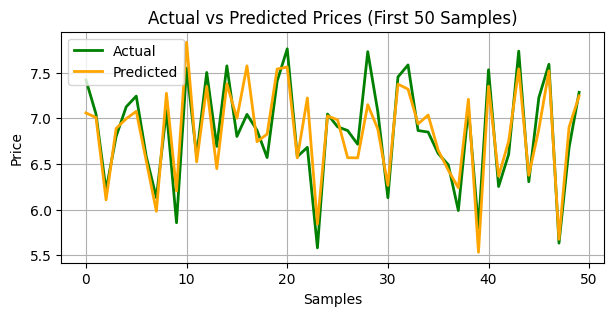

In [ ]:
# Residual Analysis plots

residuals = y_test - y_pred

plt.figure(figsize=(7,3))

plt.plot(
    y_test.values[:50],
    label="Actual",
    color="green",
    linewidth=2
)

plt.plot(
    y_pred[:50],
    label="Predicted",
    color="orange",
    linewidth=2
)

plt.title("Actual vs Predicted Prices (First 50 Samples)")
plt.xlabel("Samples")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Plot 1: Actual vs Predicted (First 50 Samples)

"""The Actual vs Predicted plot shows that the Ridge Regression model closely follows the true laptop prices across the test samples. 
Most predicted values align well with the actual observations, indicating that the model successfully captures the underlying relationship between laptop specifications and price. 
Although minor deviations are present, there are no large systematic errors, suggesting good predictive performance."""

'The Actual vs Predicted plot shows that the Ridge Regression model closely follows the true laptop prices across the test samples. \nMost predicted values align well with the actual observations, indicating that the model successfully captures the underlying relationship between laptop specifications and price. \nAlthough minor deviations are present, there are no large systematic errors, suggesting good predictive performance.'

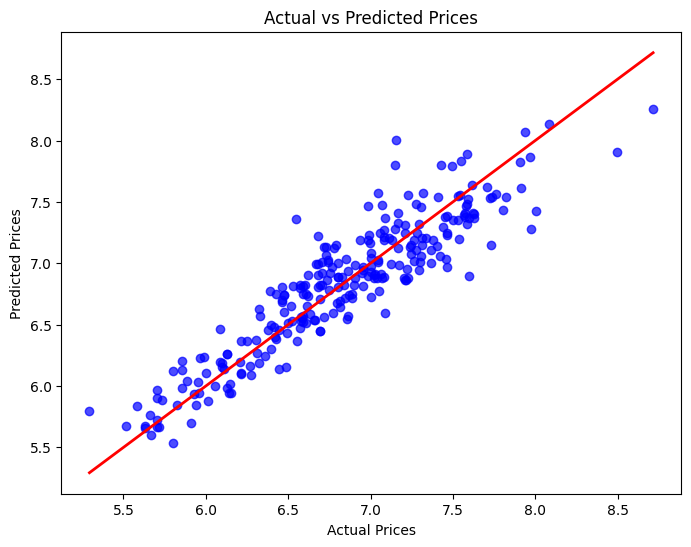

In [ ]:

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    color="blue",
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()

In [ ]:
# Plot 2: Actual vs Predicted Scatter Plot

"""
The Actual vs Predicted scatter plot demonstrates a strong agreement between the observed and predicted values. 
Most data points lie close to the ideal diagonal line, indicating that the model generates accurate predictions across a wide range of laptop prices. 
The relatively small dispersion around the reference line suggests low prediction error and strong model generalization."""

'\nThe Actual vs Predicted scatter plot demonstrates a strong agreement between the observed and predicted values. \nMost data points lie close to the ideal diagonal line, indicating that the model generates accurate predictions across a wide range of laptop prices. \nThe relatively small dispersion around the reference line suggests low prediction error and strong model generalization.'

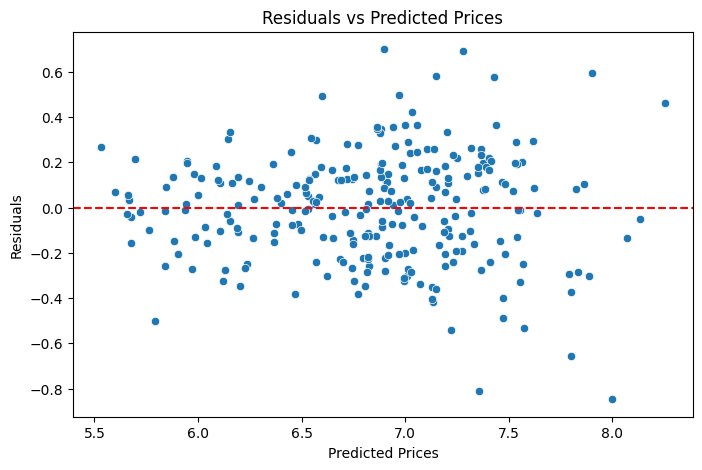

In [ ]:

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Prices")

plt.show()

# Feature Coefficients

In [ ]:
# Get feature names after preprocessing

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Get Ridge coefficients

coefficients = best_model.named_steps['model'].coef_

# Create dataframe

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute importance

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Abs_Coefficient
47,cat__Cpu_Series_Celeron,-0.503739,0.503739
48,cat__Cpu_Series_Ryzen,0.427639,0.427639
26,cat__Company_Vero,-0.386876,0.386876
21,cat__Company_Mediacom,-0.380255,0.380255
68,cat__Gpu_Series_Quadro,0.332960,0.332960
41,cat__OpSys_Windows 7,0.280664,0.280664
12,cat__Company_Chuwi,-0.274933,0.274933
34,cat__OpSys_Android,-0.269490,0.269490
18,cat__Company_LG,0.260092,0.260092
51,cat__Cpu_Series_i7,0.251947,0.251947


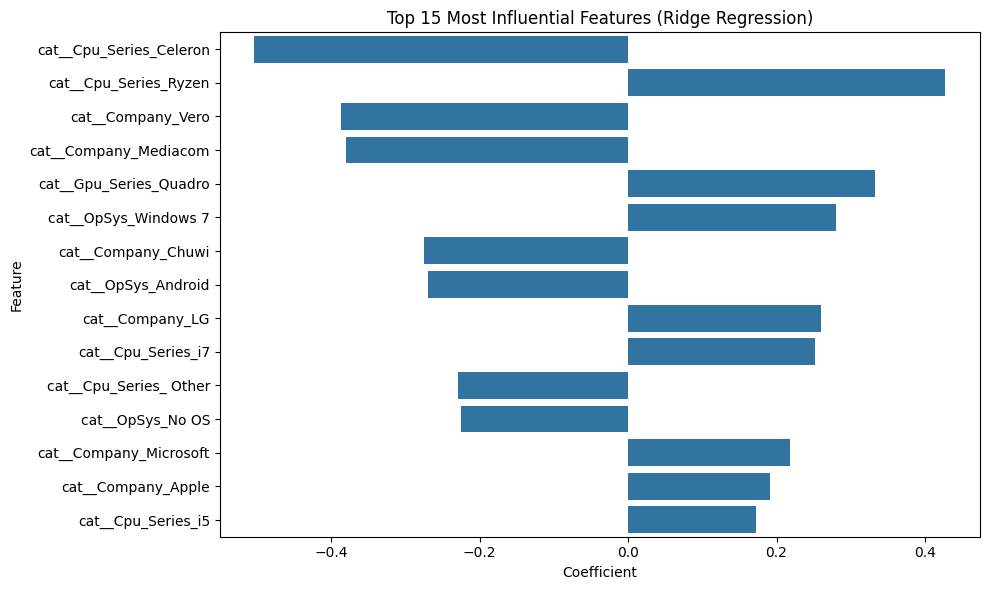

In [ ]:
top_features = coef_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title('Top 15 Most Influential Features (Ridge Regression)')
plt.tight_layout()

plt.show()

#  Product Feature Experiment 

In [ ]:
# Product Feature Experiment Insights

"""An additional experiment was conducted by removing the `Product` feature from the dataset. Initially, the model achieved a higher R² score when the product name was included. However, feature coefficient analysis revealed that specific product names dominated the model predictions, reducing interpretability.

After removing the `Product` feature, the Ridge Regression model achieved an R² score of 0.8409 with a mean cross-validation score of 0.8411. Although the predictive performance decreased slightly compared to the previous model, the resulting feature coefficients became more meaningful and reflected actual hardware characteristics such as CPU series, GPU series, RAM, storage, operating system, and company brand.

This experiment demonstrates the trade-off between predictive performance and model interpretability. For this project, the version without the `Product` feature was selected because it provides more realistic business insights and better reflects the impact of laptop specifications on pricing."""


'An additional experiment was conducted by removing the `Product` feature from the dataset. Initially, the model achieved a higher R² score when the product name was included. However, feature coefficient analysis revealed that specific product names dominated the model predictions, reducing interpretability.\n\nAfter removing the `Product` feature, the Ridge Regression model achieved an R² score of 0.8409 with a mean cross-validation score of 0.8411. Although the predictive performance decreased slightly compared to the previous model, the resulting feature coefficients became more meaningful and reflected actual hardware characteristics such as CPU series, GPU series, RAM, storage, operating system, and company brand.\n\nThis experiment demonstrates the trade-off between predictive performance and model interpretability. For this project, the version without the `Product` feature was selected because it provides more realistic business insights and better reflects the impact of lapto

# Final Model Selection

In [ ]:
# Final Model Selection Insights

"""
Several machine learning algorithms were evaluated, including Linear Regression, Ridge Regression, Lasso Regression, Random Forest, Support Vector Regression, Decision Tree, and K-Nearest Neighbors.

Based on model comparison, cross-validation performance, hyperparameter tuning results, and interpretability, Ridge Regression was selected as the final model for this project.

The final model achieved an R² score of 0.8409 and a mean cross-validation score of 0.8411. The model demonstrated stable performance across different validation folds and provided meaningful insights into the factors influencing laptop prices.

Additionally, the Product feature was excluded from the final model to improve interpretability and ensure that predictions were driven by hardware specifications rather than specific product names.
"""

'\nSeveral machine learning algorithms were evaluated, including Linear Regression, Ridge Regression, Lasso Regression, Random Forest, Support Vector Regression, Decision Tree, and K-Nearest Neighbors.\n\nBased on model comparison, cross-validation performance, hyperparameter tuning results, and interpretability, Ridge Regression was selected as the final model for this project.\n\nThe final model achieved an R² score of 0.8409 and a mean cross-validation score of 0.8411. The model demonstrated stable performance across different validation folds and provided meaningful insights into the factors influencing laptop prices.\n\nAdditionally, the Product feature was excluded from the final model to improve interpretability and ensure that predictions were driven by hardware specifications rather than specific product names.\n'

In [ ]:
# Save model
import joblib
joblib.dump(
    best_model,
    '../models/laptop_price_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
model = joblib.load(
    '../models/laptop_price_model.pkl'
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import os

print(os.path.exists('../models/laptop_price_model.pkl'))

True


In [ ]:
# Project Conclusion

"""
This project successfully developed a machine learning model for predicting laptop prices using hardware specifications and device characteristics.

The workflow included data cleaning, exploratory data analysis, feature engineering, preprocessing, model comparison, cross-validation, hyperparameter tuning, and model evaluation.

The final Ridge Regression model achieved strong predictive performance while maintaining interpretability. The project demonstrates an end-to-end machine learning workflow and highlights the importance of feature engineering in improving model performance.
"""

'\nThis project successfully developed a machine learning model for predicting laptop prices using hardware specifications and device characteristics.\n\nThe workflow included data cleaning, exploratory data analysis, feature engineering, preprocessing, model comparison, cross-validation, hyperparameter tuning, and model evaluation.\n\nThe final Ridge Regression model achieved strong predictive performance while maintaining interpretability. The project demonstrates an end-to-end machine learning workflow and highlights the importance of feature engineering in improving model performance.\n'